In [1]:
import os

train_dir = './coco/images/train/'
train_annotation = './coco/annotations/instances_attributes_train2020.json'
seg_train = './coco/segmentations/seg_train/'
val_dir = './coco/images/val/'
val_annotation = './coco/annotations/instances_attributes_val2020.json'
seg_val = './coco/segmentations/seg_val/'

print('Train contains:', len(os.listdir(train_dir)), 'images')
print('Seg_train contains:',len(os.listdir(seg_train)), 'images')
print('Validation contains:',len(os.listdir(val_dir)), 'images')
print('Seg_val contains:',len(os.listdir(seg_val)), 'images')
#print('Test contains:',len(os.listdir('./coco//content/test/')), 'images')

Train contains: 45623 images
Seg_train contains: 45623 images
Validation contains: 3200 images
Seg_val contains: 1158 images


In [2]:
#enèssim intent, istg que em matarà aquesta pràctica

In [3]:
import matplotlib.pyplot as plt
import cv2
import os
import torch
from PIL import Image
import numpy as np
from torch.utils.data import Dataset
from pycocotools.coco import COCO
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader

if torch.cuda.is_available():
    device=torch.device("cuda")
else:
    device=torch.device("cpu")

device=torch.device("cpu")
print(device)
"""
Output must be--> device(type='cuda')
"""

cpu


"\nOutput must be--> device(type='cuda')\n"

In [4]:


# Custom PyTorch Dataset to load COCO-format annotations and images
class FashionDatasetMaskRCNN(Dataset):
    # Init function: loads annotation file and prepares list of image id's
    def __init__(self, root_dir, annotation_file, transforms=None):
        """
        root_dir: path to the folder containing images (e.g. car_parts_dataset/train/)
        annotation_file: path to the COCO annotations (e.g. car_parts_dataset/train/_annotations.coco.json)
        """
        self.root_dir = root_dir  # Directory where images are stored
        self.coco = COCO(annotation_file)  # Load COCO annotations
        self.image_ids = list(self.coco.imgs.keys())  # Extract all image IDs
        self.transforms = transforms  # Optional image transformations
     
    # Returns total number of images
    def __len__(self):
        return len(self.image_ids)  # Total number of images
 
    # Fetches a single image and its annotations
    def __getitem__(self, idx):
        image_id = self.image_ids[idx]  # Get image ID from list
        image_info = self.coco.loadImgs(image_id)[0]  # Load image info (e.g. filename)
        image_path = os.path.join(self.root_dir, image_info["file_name"])  # Construct full path
        image = Image.open(image_path).convert("RGB")  # Load and convert image to RGB
         
        # Load all annotations for this image
        annotation_ids = self.coco.getAnnIds(imgIds=image_id)  # Get annotation IDs for image
        annotations = self.coco.loadAnns(annotation_ids)  # Load annotation details
         
        # Extract segmentation masks, bounding boxes and labels from annotations
        boxes = []  # List to store bounding boxes
        labels = []  # List to store category labels
        masks = []  # List to store segmentation masks
         
        for ann in annotations:
            if ann["category_id"]>27:continue
            xmin, ymin, w, h = ann['bbox']  # Get bounding box in COCO format (x, y, width, height)
            xmax = xmin + w  # Calculate bottom-right x
            ymax = ymin + h  # Calculate bottom-right y
            boxes.append([xmin, ymin, xmax, ymax])  # Append box in (xmin, ymin, xmax, ymax) format
            labels.append(ann['category_id'])  # Append category ID
            mask = self.coco.annToMask(ann)  # Convert segmentation to binary mask
            masks.append(mask)  # Append mask
         
        # Convert annotations to PyTorch tensors
        boxes = torch.as_tensor(boxes, dtype=torch.float32)  # Bounding boxes as float tensors
        labels = torch.as_tensor(labels, dtype=torch.int64)  # Labels as int64 tensors
        masks = torch.as_tensor(masks, dtype=torch.uint8)  # Masks as uint8 tensors
        area = torch.as_tensor([ann['area'] for ann in annotations], dtype=torch.float32)  # Area of each object
        iscrowd = torch.as_tensor([ann.get('iscrowd', 0) for ann in annotations], dtype=torch.int64)  # Crowd annotations
         
        # store everything in a dictionary
        target = {
            "boxes": boxes,  # Bounding boxes
            "labels": labels,  # Object labels
            "masks": masks,  # Segmentation masks
            "image_id": image_id,  # Image ID
            "area": area,  # Area of each object
            "iscrowd": iscrowd  # Crowd flags
        }
 
        # Apply transforms
        if self.transforms:
            image = self.transforms(image)  # Apply any data augmentations or preprocessing
         
        # Return the processed image and its annotations
        return image, target  # Return tuple of image and annotation dictionary

def get_transform():
    return ToTensor()
    
train_dataset = FashionDatasetMaskRCNN(
    root_dir=train_dir,
    annotation_file=train_annotation,
    transforms=get_transform()  # define this if needed
)

val_dataset = FashionDatasetMaskRCNN(
    root_dir=val_dir,
    annotation_file=val_annotation,
    transforms=get_transform()  # define this if needed
)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))

loading annotations into memory...
Done (t=5.66s)
creating index...
index created!
loading annotations into memory...
Done (t=0.18s)
creating index...
index created!


/tmp/ipykernel_117264/3184158609.py:47: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  masks = torch.as_tensor(masks, dtype=torch.uint8)  # Masks as uint8 tensors


28


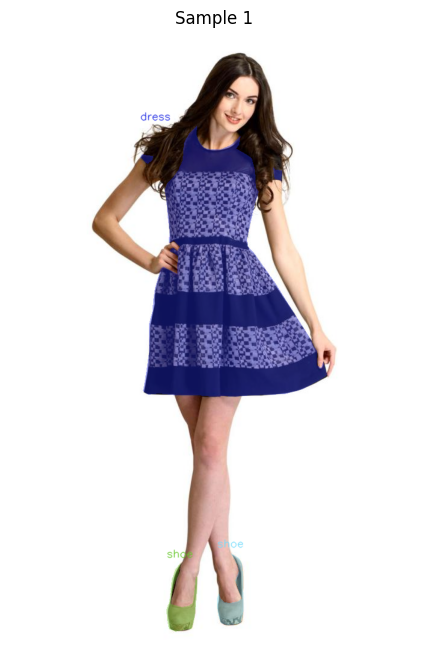

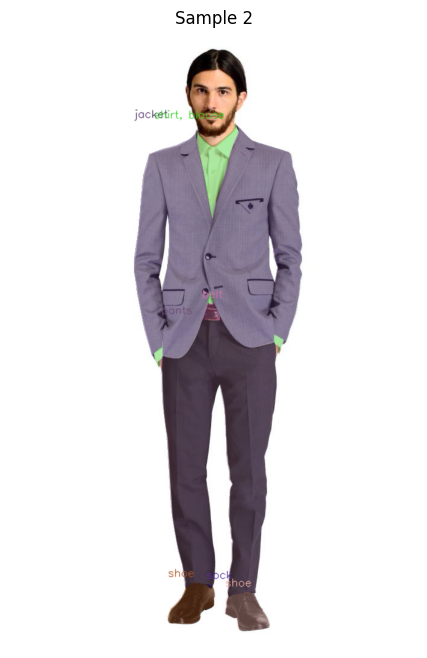

In [5]:
# Label list 
CLASS_NAMES = [ " ",
    "back_bumper", "back_glass", "back_left_door", "back_left_light", "back_right_door",
    "back_right_light", "front_bumper", "front_glass", "front_left_door", "front_left_light",
    "front_right_door", "front_right_light", "hood", "left_mirror", "right_mirror",
    "tailgate", "trunk", "wheel"
]
 

FULL_CLASSES = [' ','shirt, blouse','top, t-shirt, sweatshirt','sweater','cardigan',
                'jacket','vest','pants','shorts','skirt','coat','dress','jumpsuit',
                'cape','glasses','hat','headband, head covering, hair accessory',
                'tie','glove','watch','belt','leg warmer','tights, stockings','sock',
                'shoe','bag, wallet','scarf','umbrella','hood','collar','lapel',
                'epaulette','sleeve','pocket','neckline','buckle','zipper','applique',
                'bead','bow','flower','fringe','ribbon','rivet','ruffle','sequin','tassel']
CLASS_NAMES = FULL_CLASSES[:28]
#NUM_CLASSES = len(MAIN_CLASSES) + 1 #+1 for background

# Get one batch
images, targets = next(iter(train_loader))

print(len(CLASS_NAMES))
 
# loop through one batch and draw bounding boxes and labels
for i in range(len(images)):
    # CxHxW --> HxWxC
    image = images[i].permute(1, 2, 0).cpu().numpy()
    # Rescale
    image = (image * 255).astype(np.uint8)
    # Convert RGB to BGR
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
    overlay = image.copy()
     
    # Extract masks, bounding boxes, and labels for the current image
    masks = targets[i]['masks'].cpu().numpy()
    boxes = targets[i]['boxes'].cpu().numpy()
    labels = targets[i]['labels'].cpu().numpy()
 
    for j in range(len(masks)):
        mask = masks[j]
        box = boxes[j]
        label_id = labels[j]
 
        # Get class name from mapping
        class_name = CLASS_NAMES[label_id+1]  # assuming 1-based labels
 
        # Random color
        color = np.random.randint(0, 255, (3,), dtype=np.uint8).tolist()
 
        # Alpha blend mask
        colored_mask = np.zeros_like(image, dtype=np.uint8)
        for c in range(3):
            colored_mask[:, :, c] = mask * color[c]
        alpha = 0.4
        overlay = np.where(mask[..., None], 
                           ((1 - alpha) * overlay + alpha * colored_mask).astype(np.uint8), 
                           overlay)
 
        # Draw label
        x1, y1, x2, y2 = map(int, box)
        cv2.putText(overlay, class_name, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX,
                    0.6, color, 1, lineType=cv2.LINE_AA)
 
 
    # Show the result
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"Sample {i + 1}")
    plt.show()

In [6]:
import torchvision
from torchvision.models.detection import MaskRCNN
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
 
# Load a pre-trained Mask R-CNN model with a ResNet-50 FPN backbone
model = torchvision.models.detection.maskrcnn_resnet50_fpn(pretrained=True)
 
# Determine the number of classes (including background) from training dataset
# COCO format includes category IDs, and we add +1 for background
num_classes = len(train_dataset.coco.getCatIds()) + 1
 
# Replace the existing box predictor with a new one for our number of classes
# in_features_box: number of input features to the classification layer
in_features_box = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features_box, num_classes)
 
# Replace the existing mask predictor with a new one for our number of classes
# in_features_mask: number of input channels to the first convolutional layer 
in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
hidden_layer = 256
model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, hidden_layer, num_classes)
 
# Move the model to the specified device (e.g., GPU) for training or inference
model.to(device)

/mnt/a27b1cbf-298a-4896-8528-84006d36fd9e/Nero/Documents/Acadèmic/UPC - MAMME/OR/P2/OR_task2/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/mnt/a27b1cbf-298a-4896-8528-84006d36fd9e/Nero/Documents/Acadèmic/UPC - MAMME/OR/P2/OR_task2/venv/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MaskRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=MaskRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


MaskRCNN(
  (transform): GeneralizedRCNNTransform(
      Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
      Resize(min_size=(800,), max_size=1333, mode='bilinear')
  )
  (backbone): BackboneWithFPN(
    (body): IntermediateLayerGetter(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): FrozenBatchNorm2d(64, eps=0.0)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): FrozenBatchNorm2d(64, eps=0.0)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): FrozenBatchNorm2d(64, eps=0.0)
          (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn3): FrozenBatchNorm2d(256, eps=0.0)
          (relu): ReLU(in

In [7]:
# Get parameters that require gradients (the model's trainable parameters)
params = [p for p in model.parameters() if p.requires_grad]
 
# Define the optimizer SGD(Stochastic Gradient Descent) 
optimizer = torch.optim.SGD(params, lr=0.005,
                            momentum=0.9, weight_decay=0.0005)

In [8]:
from maskrcnn_engine import train_one_epoch, evaluate
 
# Number of epochs for training
num_epochs = 2
 
# Loop through each epoch
for epoch in range(num_epochs):
    print(f"\nEpoch {epoch + 1}/{num_epochs}")
 
    # Train the model for one epoch, printing status every 25 iterations
    train_one_epoch(model, optimizer, train_loader, device, epoch, print_freq=25)  # Using train_loader for training
 
    # Evaluate the model on the validation dataset
    evaluate(model, val_loader, device=device)  # Using val_loader for evaluation
 
    # Optionally, save the model checkpoint after each epoch
    torch.save(model.state_dict(), f"model_epoch_{epoch + 1}.pth")

/mnt/a27b1cbf-298a-4896-8528-84006d36fd9e/Nero/Documents/Acadèmic/UPC - MAMME/OR/P2/OR_task2/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



Epoch 1/2
loss_dict {'loss_classifier': tensor(3.5386, grad_fn=<NllLossBackward0>), 'loss_box_reg': tensor(0.1853, grad_fn=<DivBackward0>), 'loss_mask': tensor(1.4760, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>), 'loss_objectness': tensor(0.0480, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>), 'loss_rpn_box_reg': tensor(0.0055, grad_fn=<DivBackward0>)}
Epoch: [0]  [    0/22812]  eta: 6 days, 15:55:24  lr: 0.000010  loss: 5.2535 (5.2535)  loss_classifier: 3.5386 (3.5386)  loss_box_reg: 0.1853 (0.1853)  loss_mask: 1.4760 (1.4760)  loss_objectness: 0.0480 (0.0480)  loss_rpn_box_reg: 0.0055 (0.0055)  time: 25.2378  data: 0.7142  max mem: 0
loss_dict {'loss_classifier': tensor(3.4456, grad_fn=<NllLossBackward0>), 'loss_box_reg': tensor(0.3837, grad_fn=<DivBackward0>), 'loss_mask': tensor(1.1436, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>), 'loss_objectness': tensor(0.2305, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>), 'loss_rpn_box_reg': tensor(0.0298, grad_fn=<DivBackward0

KeyboardInterrupt: 

In [ ]:
model.state_dict()